In [1]:
import pandas as pd

# Read the CSV file
df = pd.read_csv('dempsey_cleaned_data.csv')

# Display basic information
print(f"Shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (1047, 10)

Column names:
['Year', 'Satisfaction', 'LifeBetter', 'Age', 'Gender', 'ServiceFreq', 'CancerStatus', 'TreatmentStage', 'Income', 'HighSatisfaction']

First 5 rows:


,Year,Satisfaction,LifeBetter,Age,Gender,ServiceFreq,CancerStatus,TreatmentStage,Income,HighSatisfaction
0,2022,Very Satisfied,Yes,65-74,Woman,6-9 times,I have had cancer,No Evidence of Disease,NaN,1
1,2022,Very Satisfied,Yes,55-64,Woman,1 time,I have had cancer,Post-treatment,NaN,1
2,2022,Very Satisfied,Yes,75 or older,Woman,More than 10 times,I have had cancer,Post-treatment,NaN,1
3,2022,Very Satisfied,Yes,55-64,Woman,More than 10 times,I have had cancer,Post-treatment,NaN,1
4,2022,Very Satisfied,Yes,65-74,Woman,2-5 times,I currently have cancer,Post-treatment,NaN,1


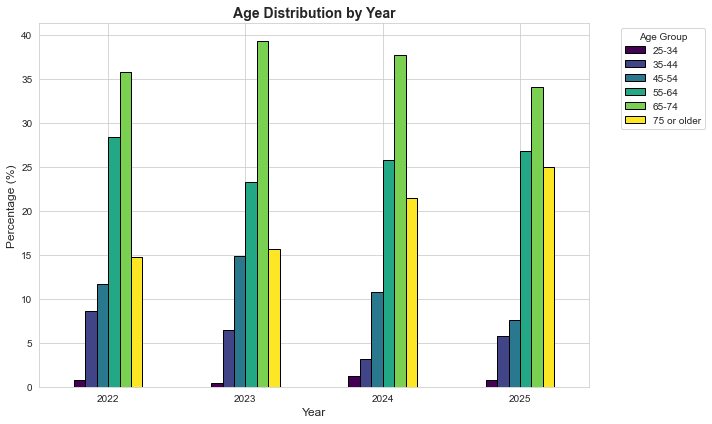

Age Distribution by Year (%):


Age,25-34,35-44,45-54,55-64,65-74,75 or older
Year,,,,,,
2022,0.78,8.56,11.67,28.40,35.80,14.79
2023,0.38,6.49,14.89,23.28,39.31,15.65
2024,1.19,3.17,10.71,25.79,37.70,21.43
2025,0.72,5.80,7.61,26.81,34.06,25.00


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Calculate age distribution by year
age_by_year = pd.crosstab(df['Year'], df['Age'], normalize='index') * 100

# Plot
ax = age_by_year.plot(kind='bar', stacked=False, colormap='viridis', edgecolor='black')
plt.title('Age Distribution by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Display the data table
print("Age Distribution by Year (%):")
age_by_year.round(2)

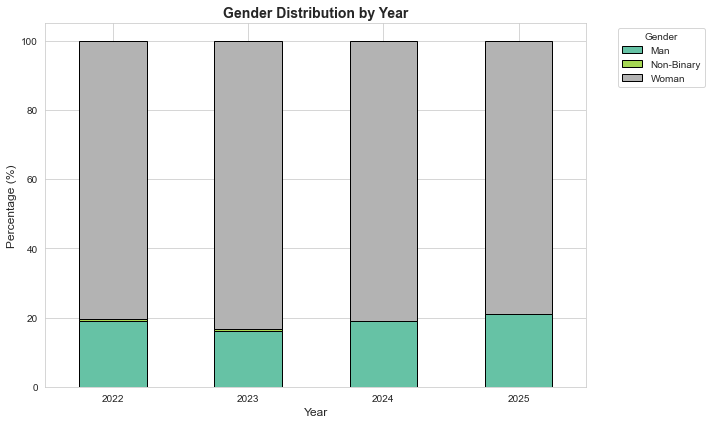

Gender Distribution by Year (%):


Gender,Man,Non-Binary,Woman
Year,,,
2022,19.07,0.39,80.54
2023,16.03,0.76,83.21
2024,19.05,0.00,80.95
2025,21.01,0.00,78.99


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Calculate gender distribution by year
gender_by_year = pd.crosstab(df['Year'], df['Gender'], normalize='index') * 100

# Plot
ax = gender_by_year.plot(kind='bar', stacked=True, colormap='Set2', edgecolor='black')
plt.title('Gender Distribution by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Display the data table
print("Gender Distribution by Year (%):")
gender_by_year.round(2)

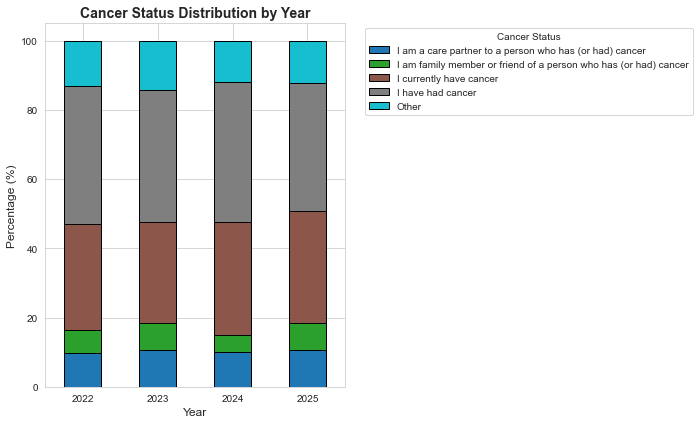

Cancer Status Distribution by Year (%):


CancerStatus,I am a care partner to a person who has (or had) cancer,I am family member or friend of a person who has (or had) cancer,I currently have cancer,I have had cancer,Other
Year,,,,,
2022,9.73,6.61,30.74,39.69,13.23
2023,10.69,7.63,29.39,38.17,14.12
2024,9.92,5.16,32.54,40.48,11.90
2025,10.51,7.97,32.25,36.96,12.32


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Merge the two 'other' cancer status responses into one category
cancer_status_clean = df['CancerStatus'].replace({
    'Other / prefer to self-describe:': 'Other',
    'Other/prefer to self-describe:': 'Other'
})

# Calculate cancer status distribution by year
cancer_status_by_year = pd.crosstab(df['Year'], cancer_status_clean, normalize='index') * 100

# Plot
ax = cancer_status_by_year.plot(kind='bar', stacked=True, colormap='tab10', edgecolor='black')
plt.title('Cancer Status Distribution by Year', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Cancer Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Display the data table
print("Cancer Status Distribution by Year (%):")
cancer_status_by_year.round(2)

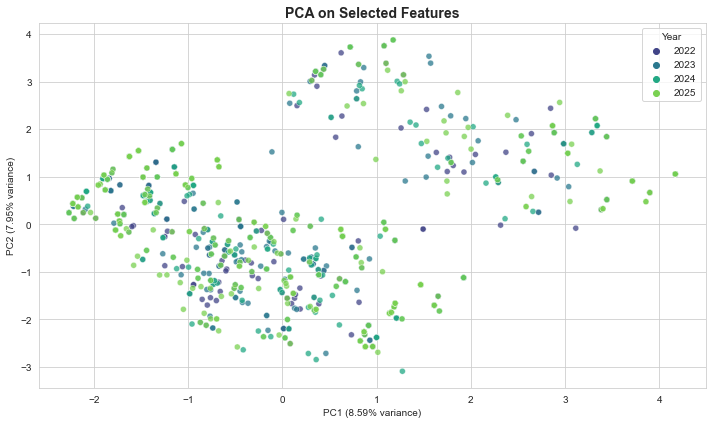

Explained variance ratio:
PC1: 8.59%
PC2: 7.95%
Total (PC1+PC2): 16.53%

Top 10 features by absolute loading on PC1:
Gender_Woman                             0.440623
Gender_Man                               0.440514
CancerStatus_I currently have cancer     0.431029
CancerStatus_I have had cancer           0.408452
TreatmentStage_Currently in treatment    0.330239
TreatmentStage_Post-treatment            0.215650
Age_75 or older                          0.195832
TreatmentStage_No Evidence of Disease    0.145137
Age_55-64                                0.125418
ServiceFreq_More than 10 times           0.089946
Name: PC1_loading, dtype: float64

Top 10 features by absolute loading on PC2:
Gender_Woman                             0.429150
Gender_Man                               0.425828
CancerStatus_I have had cancer           0.403808
TreatmentStage_Currently in treatment    0.370316
CancerStatus_I currently have cancer     0.224281
TreatmentStage_Post-treatment            0.203665
Trea

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1) Only use selected columns for PCA
selected_features = ['Age', 'Gender', 'ServiceFreq', 'CancerStatus', 'TreatmentStage']
missing_cols = [c for c in selected_features if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataframe: {missing_cols}")

pca_data = df[selected_features].copy()

# Keep CancerStatus labeling consistent
pca_data['CancerStatus'] = pca_data['CancerStatus'].replace({
    'Other / prefer to self-describe:': 'Other',
    'Other/prefer to self-describe:': 'Other'
})

# 2) Handle missing values and one-hot encode
pca_data = pca_data.fillna('Missing')
X = pd.get_dummies(pca_data, drop_first=False)

# 3) Standardize then run PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4) Build result dataframe for visualization
pca_result = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
if 'Year' in df.columns:
    pca_result['Year'] = df['Year'].astype(str)

# 5) Plot PCA scatter
plt.figure(figsize=(10, 6))
if 'Year' in pca_result.columns:
    sns.scatterplot(data=pca_result, x='PC1', y='PC2', hue='Year', palette='viridis', alpha=0.75)
else:
    sns.scatterplot(data=pca_result, x='PC1', y='PC2', alpha=0.75)

plt.title('PCA on Selected Features', fontsize=14, fontweight='bold')
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.tight_layout()
plt.show()

# 6) Explained variance summary
print('Explained variance ratio:')
print(f"PC1: {pca.explained_variance_ratio_[0] * 100:.2f}%")
print(f"PC2: {pca.explained_variance_ratio_[1] * 100:.2f}%")
print(f"Total (PC1+PC2): {pca.explained_variance_ratio_.sum() * 100:.2f}%")

# 7) Top contributing features for each principal component
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=['PC1_loading', 'PC2_loading'])
print('\nTop 10 features by absolute loading on PC1:')
print(loadings['PC1_loading'].abs().sort_values(ascending=False).head(10))
print('\nTop 10 features by absolute loading on PC2:')
print(loadings['PC2_loading'].abs().sort_values(ascending=False).head(10))

Encoded feature dimension: 27
Best k by silhouette score (high-dimensional space): 2

Cluster sizes:
0    847
1    200
Name: Cluster, dtype: int64


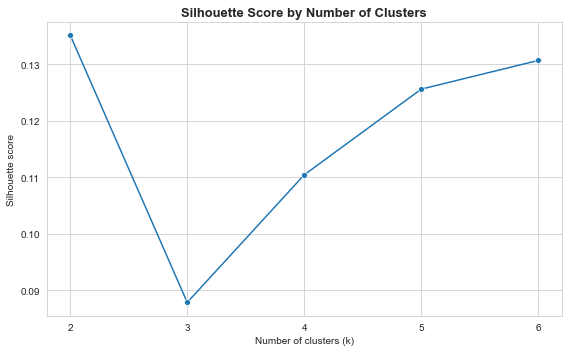

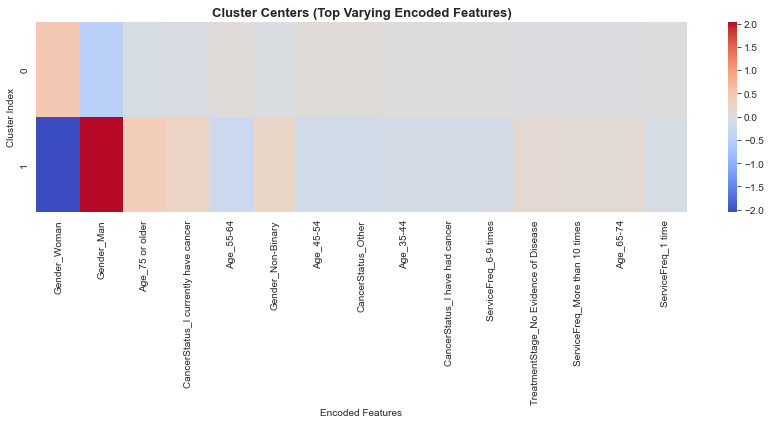


Top encoded features that differentiate clusters:
Gender_Woman                             3.235564
Gender_Man                               3.175782
Age_75 or older                          0.113464
CancerStatus_I currently have cancer     0.049262
Age_55-64                                0.048611
Gender_Non-Binary                        0.039375
Age_45-54                                0.024787
CancerStatus_Other                       0.023631
Age_35-44                                0.016713
CancerStatus_I have had cancer           0.014782
ServiceFreq_6-9 times                    0.012487
TreatmentStage_No Evidence of Disease    0.011213
ServiceFreq_More than 10 times           0.009661
Age_65-74                                0.009324
ServiceFreq_1 time                       0.007200
dtype: float64


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1) Select features for clustering (directly in original high-dimensional encoded space)
cluster_features = ['Age', 'Gender', 'ServiceFreq', 'CancerStatus', 'TreatmentStage']
missing_cols = [c for c in cluster_features if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataframe: {missing_cols}")

cluster_data = df[cluster_features].copy()

# Keep CancerStatus labeling consistent
cluster_data['CancerStatus'] = cluster_data['CancerStatus'].replace({
    'Other / prefer to self-describe:': 'Other',
    'Other/prefer to self-describe:': 'Other'
})

# 2) Preprocess: one-hot encode to high-dimensional feature space, then standardize
cluster_data = cluster_data.fillna('Missing')
X_cluster = pd.get_dummies(cluster_data, drop_first=False)

scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

print(f"Encoded feature dimension: {X_cluster.shape[1]}")

# 3) Search best k by silhouette score on high-dimensional data
k_candidates = list(range(2, 7))
silhouette_scores = []
for k in k_candidates:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels_k)
    silhouette_scores.append(score)

best_k = k_candidates[int(pd.Series(silhouette_scores).idxmax())]
print(f"Best k by silhouette score (high-dimensional space): {best_k}")

# 4) Fit final model in high-dimensional space
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_scaled)

cluster_result = df.copy()
cluster_result['Cluster'] = cluster_labels.astype(str)

# 5) Cluster size summary
print('\nCluster sizes:')
print(cluster_result['Cluster'].value_counts().sort_index())

# 6) Silhouette score trend plot
score_df = pd.DataFrame({'k': k_candidates, 'silhouette_score': silhouette_scores})
plt.figure(figsize=(8, 5))
sns.lineplot(data=score_df, x='k', y='silhouette_score', marker='o')
plt.title('Silhouette Score by Number of Clusters', fontsize=13, fontweight='bold')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette score')
plt.xticks(k_candidates)
plt.tight_layout()
plt.show()

# 7) Interpret clusters directly in high-dimensional space
centers_scaled = pd.DataFrame(kmeans.cluster_centers_, columns=X_cluster.columns)
feature_variation = centers_scaled.var(axis=0).sort_values(ascending=False)
top_features = feature_variation.head(15).index
centers_top = centers_scaled[top_features]

plt.figure(figsize=(12, 6))
sns.heatmap(centers_top, cmap='coolwarm', center=0)
plt.title('Cluster Centers (Top Varying Encoded Features)', fontsize=13, fontweight='bold')
plt.xlabel('Encoded Features')
plt.ylabel('Cluster Index')
plt.tight_layout()
plt.show()

print('\nTop encoded features that differentiate clusters:')
print(feature_variation.head(15))